In [1]:
###!/usr/bin/env python
################################################
# New style 
# ###############################################
import sys
import os


from Utils import GridUtils as GrU
from Utils import utils as uti
from Utils import MyConstants as Co

#from PyRegridding.Utils import MakePressures as MkP
#from Drivers import RegridField as RgF
import RegridField as RgF
import update_config as uc

# The usual
from datetime import date
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# Some other useful packages 
import copy
import time
import cftime
import yaml
import numbers

# Some other useful packages 
import importlib
from pathlib import Path



 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 
Using Flexible parallel/serial VertRegrid 
 Utils.MyConstants in /glade/work/juliob/HiRes_ana_dev/Drivers/Utils 


In [2]:
year,month,day,hour=2016,8,15,0
date_=f"{year:04d}-{month:02d}-{day:02d}-{hour*3_600:05d}"
print( date_ )


2016-08-15-00000


In [3]:
' /glade/campaign/cgd/amp/juliob/mpasa3p75km/  2016-08-15-00000   PHIS_dyamond_UHR_SAndesAP.  2016-08-15-00000.nc'
f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/TimeInvariant/PHIS_dyamond_UHR_SAndesAP.nc'

####f='/glade/derecho/scratch/juliob/mpasa3p75km/2016-08-17-21600/Upwp_dyamond_ne16pg3_fv1x1.2016-08-17-21600.nc'
X = xr.open_dataset( f )

phis=X.PHIS.values

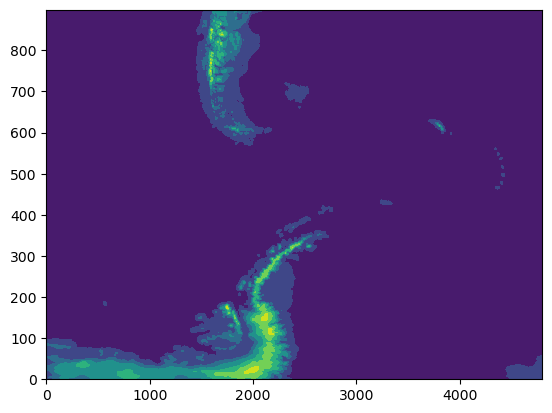

In [4]:
plt.contourf(phis)

In [20]:
f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/{date_}/w_mpas_dyamond_UHR_SAndesAP.{date_}.nc'
X = xr.open_dataset( f )
w=X.w_mpas.values

f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/{date_}/theta_mpas_dyamond_UHR_SAndesAP.{date_}.nc'
X = xr.open_dataset( f )
th=X.theta_mpas.values

f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/{date_}/T_dyamond_UHR_SAndesAP.{date_}.nc'
X = xr.open_dataset( f )
te=X.T.values

f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/{date_}/U_dyamond_UHR_SAndesAP.{date_}.nc'
X = xr.open_dataset( f )
u=X.U.values

f=f'/glade/campaign/cgd/amp/juliob/mpasa3p75km/{date_}/U_prt_dyamond_UHR_SAndesAP.{date_}.nc'
X = xr.open_dataset( f )
up=X.U_prt.values

In [ ]:
X.lev

In [8]:
#up=u-np.average(u,axis=3)
up2 = u - np.mean(u, axis=3, keepdims=True)


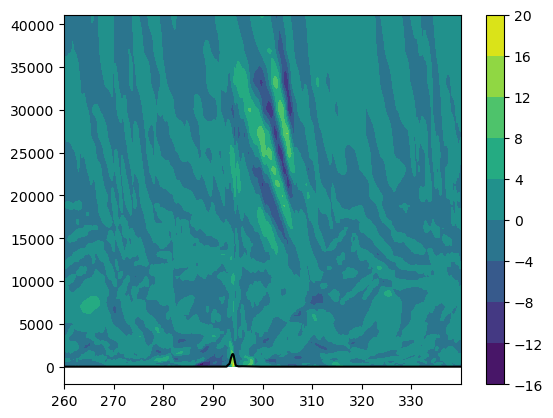

In [11]:
plt.contourf(X.lon.values,X.lev.values,up[0,:,200,:]) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

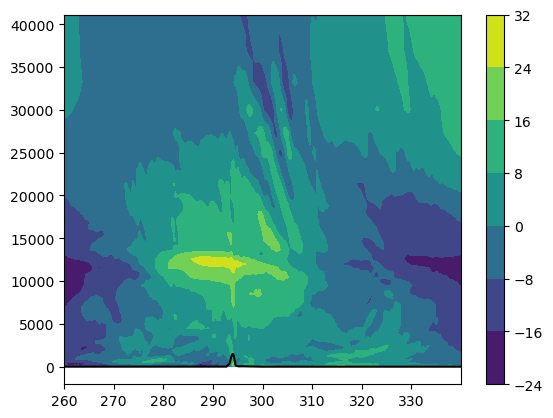

In [12]:
plt.contourf(X.lon.values,X.lev.values,up2[0,:,200,:]) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

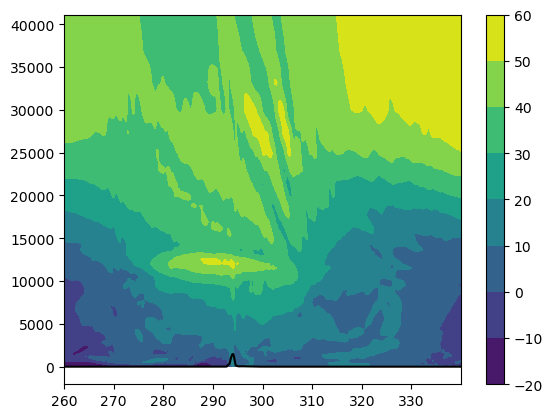

In [13]:
plt.contourf(X.lon.values,X.lev.values,u[0,:,200,:]) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

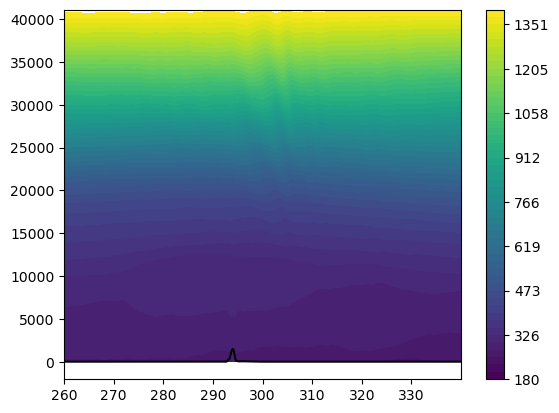

In [18]:
plt.contourf(X.lon.values,X.lev.values,th[0,:,200,:] , levels=np.linspace( 180, 1400, num=51 ) ) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

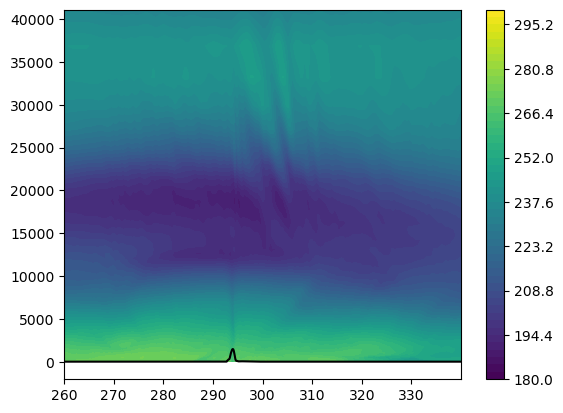

In [22]:
plt.contourf(X.lon.values,X.lev.values,te[0,:,200,:] , levels=np.linspace( 180, 300, num=51 ) ) 
plt.plot( X.lon,phis[200,:]/9.8, 'black' )
#plt.xlim(290,310)
plt.colorbar()

In [ ]:
z,y=9,200
print(X.lat.values[y],X.ilev.values[z])
fig,ax=plt.subplots( figsize=(20,10) )
c=ax.contourf(X.lon.values,X.lat.values,w[0,30,:,:],levels=np.linspace(2*(-39/2.)/19.5 ,2*(39/2.)/19.5, num=40) , cmap='bwr')
#plt.xlim(290,310)
#plt.ylim(-72,-60)
cbar = plt.colorbar(c)
cbar.set_ticks( np.linspace(-2,2,num=11) ) #[-2,-1,0,1,2] )

In [ ]:
upwp=X.Upwp.values
ilev=X.ilev.values


In [ ]:
print(ilev[10])

In [ ]:
plt.contourf( upwp[0,10,:,:] )
plt.colorbar()

In [ ]:
var=X['U'].values

In [ ]:
print( np.shape( var ) )

In [ ]:

####################################################################
# Results for 3.75 DYAMOND runs ...
# In /glade/campaign/cesm/km-scale/archive/
#
# cam77_dyamond1_prod1
# c124_dyamond1_prod2
#
# where the cam77 is the vanilla 'nodeep' run, and c124 is the 'clubb-mf' run.
#
# exmaple extraction :
#   ncks -O -v w_mpas,lat,lon c124_dyamond1_prod2.cam.h1i.2016-08-17-32400.nc /glade/derecho/scratch/juliob/w_mpas_dyamond.nc
# Adam's plll esmf ...
# /glade/campaign/cgd/amp/aherring/mpas-uniform/mpasa3p75/analysis/ESMF_parallel/ESMF_parallel.sh
#
# Making a background field (w_mpas for example)
# Regrid conseveatively from mpasa3p75km to ne16pg3:
#   ncremap -m /glade/work/juliob/HiRes_ana_dev/Drivers/mpasa3p75_TO_ne16pg3_cnsrv.nc w_mpas_dyamond.nc w_mpas_dyamond_ne16pg3.nc
# Then remap back (bilin) from ne16pg3 to mpasa3p75km to obtain the background on mpasa3p75km:
#   ncremap -m /glade/work/juliob/HiRes_ana_dev/Drivers/ne16pg3_TO_mpasa3p75_bilin.nc w_mpas_dyamond_ne16pg3.nc w_mpas_dyamond_ne16pg3_mpasa3p75.nc 

f='/glade/derecho/scratch/juliob/mpasa3p75km/U_dyamond.nc'
U=xr.open_dataset( f )
f='/glade/derecho/scratch/juliob/mpasa3p75km/U_dyamond_ne16pg3_mpasa3p75.nc'
Ubk=xr.open_dataset( f )
f='/glade/derecho/scratch/juliob/mpasa3p75km/w_mpas_dyamond.nc'
W=xr.open_dataset( f )
f='/glade/derecho/scratch/juliob/mpasa3p75km/w_mpas_dyamond_ne16pg3_mpasa3p75.nc'
Wbk=xr.open_dataset( f )





In [ ]:
%%time

lon=U.lon.values
lat=U.lat.values
u=U.U.values
ubk=Ubk.U.values
w=W.w_mpas.values
wbk=Wbk.w_mpas.values


In [ ]:
U

In [ ]:
print(U.lev.values[10])

In [ ]:
up=u-ubk
wp=w-wbk

In [ ]:
import matplotlib.pyplot as plt

plt.scatter( lon[0:100_000] , lat[0:100_000] )



#plt.tricontourf( lon,lat,up[0,20,:] )

In [ ]:
yoo=np.where( (lat<-40.)&(lat >-70.)&(lon>250.) )

In [ ]:
upwp=up*wp[:,1:,:]

In [ ]:
wlev=np.linspace( -2,2, num=51 )

plt.tricontourf( lon[yoo[0][:]] , lat[yoo[0][:]] , upwp[0,10, yoo[0][:] ] , levels=wlev, cmap='bwr'  )

plt.colorbar()

In [ ]:
coords = dict( 
    time = ( ["time"],  U.time.values ),
    lev  = ( ["lev"],U.lev.values),
    ilev = ( ["ilev"],U.ilev.values),
)


Xout = xr.Dataset( coords=coords  )

dims = ('ncol' )
Dar = xr.DataArray( data=U.lon.values , 
                    dims=dims,)
Xout[ 'lon' ]= Dar

dims = ('ncol' )
Dar = xr.DataArray( data=U.lat.values , 
                    dims=dims,)
Xout[ 'lat' ]= Dar



new_attributes = {
    'units': 'm+2 s-2',
    'long_name': 'flux up x wp',}

dims = ('time','lev','ncol' )
Dar = xr.DataArray( data=upwp , 
                    dims=dims,
                    attrs=new_attributes ,) 
                        
Xout[ 'upwp' ]= Dar
f='/glade/derecho/scratch/juliob/mpasa3p75km/UpWp_dyamond.nc'

Xout.to_netcdf( f )


In [ ]:
%%time

#####################################
# Initialize regrid-object library
RgObLib={}


RgOb_ne240_x_ne16   = GrU.regrid_object_lib(RgOb=RgObLib, src='mpasa3_75',dst='ne240pg3',  RegridMethod='BILINEAR'   ) #'CONSERVE_2ND')


In [ ]:
import subprocess

infile = "c124_dyamond1_prod2.cam.h1i.2016-08-17-32400.nc"
tmp1   = "/glade/derecho/scratch/juliob/w_mpas_dyamond.nc"
tmp2   = "w_mpas_dyamond_ne16pg3.nc"
outfile= "w_mpas_dyamond_ne16pg3_mpasa3p75.nc"

cmds = [
    # extract variable
    f"ncks -O -v w_mpas,lat,lon {infile} {tmp1}",

    # conservative remap mpasa3p75km -> ne16pg3
    "ncremap -m /glade/work/juliob/HiRes_ana_dev/Drivers/mpasa3p75_TO_ne16pg3_cnsrv.nc "
    f"{tmp1} {tmp2}",

    # bilinear remap ne16pg3 -> mpasa3p75km
    "ncremap -m /glade/work/juliob/HiRes_ana_dev/Drivers/ne16pg3_TO_mpasa3p75_bilin.nc "
    f"{tmp2} {outfile}",
]

for c in cmds:
    print("Running:", c)
    result = subprocess.run(c, shell=True)

    if result.returncode != 0:
        raise RuntimeError(f"Command failed: {c}")

print("All done.")


In [ ]:
import subprocess

subprocess.run(
    ["ncks", "-O", "-v", "w_mpas,lat,lon",
     "c124_dyamond1_prod2.cam.h1i.2016-08-17-32400.nc",
     "/glade/derecho/scratch/juliob/w_mpas_dyamond.nc"],
    check=True
)

subprocess.run(
    ["ncremap", "-m", "/glade/work/juliob/HiRes_ana_dev/Drivers/mpasa3p75_TO_ne16pg3_cnsrv.nc",
     "w_mpas_dyamond.nc",
     "w_mpas_dyamond_ne16pg3.nc"],
    check=True
)

subprocess.run(
    ["ncremap", "-m", "/glade/work/juliob/HiRes_ana_dev/Drivers/ne16pg3_TO_mpasa3p75_bilin.nc",
     "w_mpas_dyamond_ne16pg3.nc",
     "w_mpas_dyamond_ne16pg3_mpasa3p75.nc"],
    check=True
)

print("All done.")
